# Problemas de distribución de probabilidad

## Distribución binomial

En teoría de la probabilidad y estadística, la distribución binomial es la distribución de probabilidad discreta que da sólo dos resultados posibles en un experimento; por ejemplo, al lanzar una moneda, puede salir cara o cruz.

In [ ]:
from scipy.stats import binom

# Definir todas las funciones de probabilidad relacionadas con esta distribución.

def dbinom(x, size, prob = 0.5):
    """
    Calcula la estimación puntual de la distribución binomial.
    """
    result = binom.pmf(k = x, n = size, p = prob, loc = 0)

    return result

def pbinom(q, size, prob = 0.5):
    """
    Calcula el acumulado de la distribución binomial.
    """
    result = binom.cdf(k = q, n = size, p = prob, loc = 0)

    return result

def qbinom(p, size, prob = 0.5):
    """
    Calcula la función cuantil a partir de la distribución binomial.
    """
    result = binom.ppf(q = p, n = size, p = prob, loc = 0)

    return result

def rbinom(n, size, prob = 0.5):
    """
    Genera variables aleatorias a partir de la distribución binomial.
    """
    result = binom.rvs(n = size, p = prob, size = n)

    return result

In [ ]:
# Distribución binomial(10, 0.2), dónde n = 10 es el número de ensayos y p = 0.2 es la probabilidad de éxito en un solo ensayo
import numpy as np

np.random.seed(42)

print(f"Probability that a Binomial(10, 0.2) takes the value 2: {dbinom(2, size = 10, prob = 0.2)}")
print(f"Probability that a Binomial(10, 0.2) will take a value less than 2: {pbinom(2, size = 10, prob = 0.2)}")
print(f"Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? {qbinom(0.9, size = 10, prob = 0.2)}")
print(f"Generate 2000 random values from a Binomial(10, 0.2) distribution: {rbinom(2000, size = 10, prob = 0.2)}")

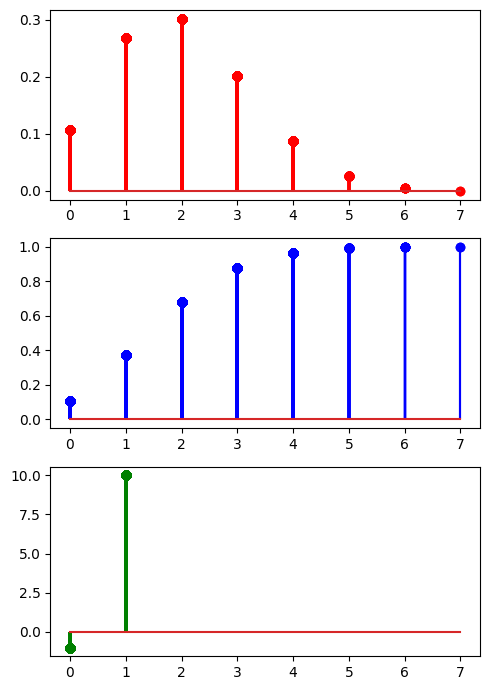

In [ ]:
import matplotlib.pyplot as plt

np.random.seed(42)

size = 10
prob = 0.2
data = rbinom(2000, size = 10, prob = 0.2)

pmf = dbinom(data, size = size, prob = prob)
cdf = pbinom(data, size = size, prob = prob)
ppf = qbinom(data, size = size, prob = prob)

fig, axis = plt.subplots(3, 1, figsize = (5, 7))

axis[0].stem(data, pmf, "r-")
axis[1].stem(data, cdf, "b-")
axis[2].stem(data, ppf, "g-")

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

## Ejercicio 1

Escriba las funciones anteriores pero para distribuciones normales y uniformes.

In [1]:
from scipy.stats import norm, uniform
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def normal_density(x, mu=0, sigma=1):
    """
    Devuelve la densidad (PDF) de una distribución normal.
    """
    return norm.pdf(x, loc=mu, scale=sigma)


def normal_cumulative(x, mu=0, sigma=1):
    """
    Devuelve la probabilidad acumulada (CDF) hasta x.
    """
    return norm.cdf(x, loc=mu, scale=sigma)


def normal_quantile(prob, mu=0, sigma=1):
    """
    Devuelve el valor x asociado a una probabilidad acumulada dada.
    """
    return norm.ppf(prob, loc=mu, scale=sigma)


def normal_random_sample(n, mu=0, sigma=1, seed=None):
    """
    Genera n valores aleatorios desde una distribución normal.
    """
    if seed is not None:
        np.random.seed(seed)
    return norm.rvs(loc=mu, scale=sigma, size=n)

In [3]:
def uniform_density(x, a=0, b=1):
    """
    Devuelve la densidad (PDF) de una distribución uniforme.
    """
    return uniform.pdf(x, loc=a, scale=b - a)


def uniform_cumulative(x, a=0, b=1):
    """
    Devuelve la probabilidad acumulada (CDF) hasta x.
    """
    return uniform.cdf(x, loc=a, scale=b - a)


def uniform_quantile(prob, a=0, b=1):
    """
    Devuelve el valor x asociado a una probabilidad acumulada dada.
    """
    return uniform.ppf(prob, loc=a, scale=b - a)


def uniform_random_sample(n, a=0, b=1, seed=None):
    """
    Genera n valores aleatorios desde una distribución uniforme.
    """
    if seed is not None:
        np.random.seed(seed)
    return uniform.rvs(loc=a, scale=b - a, size=n)

In [4]:
mu = 0
sigma = 1

x_normal = np.linspace(-4, 4, 500)

p_values = np.linspace(0.01, 0.99, 500)

normal_pdf_values = normal_density(x_normal, mu=mu, sigma=sigma)
normal_cdf_values = normal_cumulative(x_normal, mu=mu, sigma=sigma)
normal_ppf_values = normal_quantile(p_values, mu=mu, sigma=sigma)

print("Normal distribution N(0,1)")
print("Density at x = 0:", normal_density(0, mu=mu, sigma=sigma))
print("Cumulative probability up to x = 1.5:", normal_cumulative(1.5, mu=mu, sigma=sigma))
print("Value associated with probability 0.95:", normal_quantile(0.95, mu=mu, sigma=sigma))
print("Random sample of 10 values:", normal_random_sample(10, mu=mu, sigma=sigma, seed=42))

Normal distribution N(0,1)
Density at x = 0: 0.3989422804014327
Cumulative probability up to x = 1.5: 0.9331927987311419
Value associated with probability 0.95: 1.6448536269514722
Random sample of 10 values: [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337 -0.23413696
  1.57921282  0.76743473 -0.46947439  0.54256004]


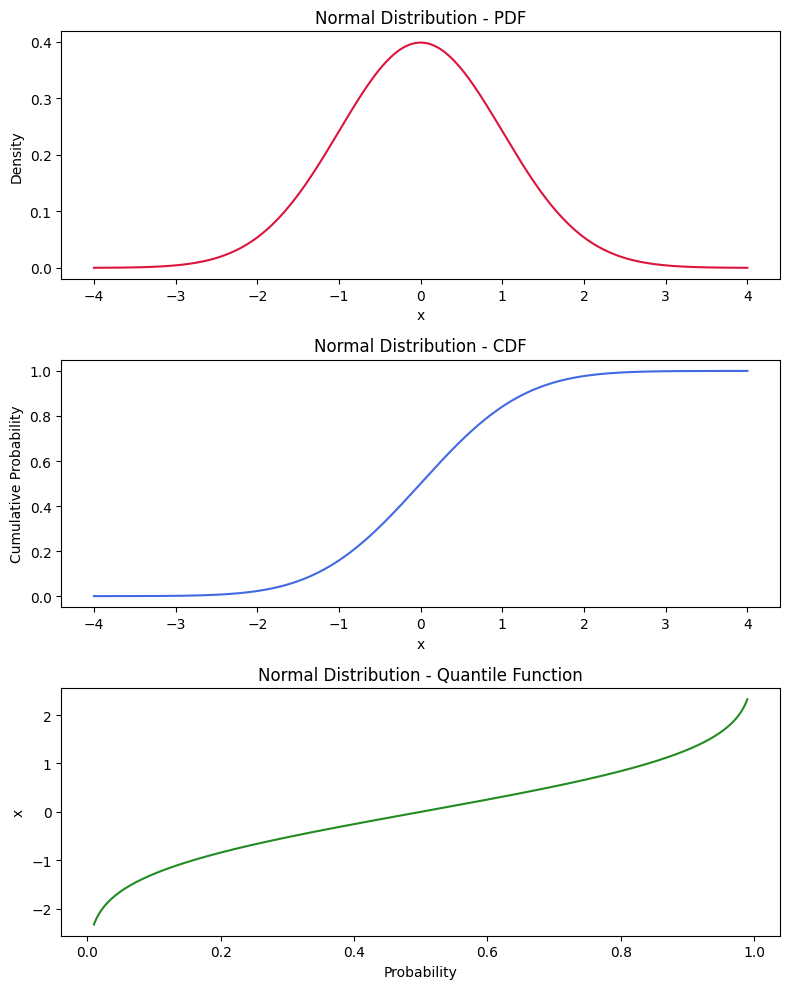

In [5]:
fig, ax = plt.subplots(3, 1, figsize=(8, 10))

ax[0].plot(x_normal, normal_pdf_values, color="crimson")
ax[0].set_title("Normal Distribution - PDF")
ax[0].set_xlabel("x")
ax[0].set_ylabel("Density")

ax[1].plot(x_normal, normal_cdf_values, color="royalblue")
ax[1].set_title("Normal Distribution - CDF")
ax[1].set_xlabel("x")
ax[1].set_ylabel("Cumulative Probability")

ax[2].plot(p_values, normal_ppf_values, color="forestgreen")
ax[2].set_title("Normal Distribution - Quantile Function")
ax[2].set_xlabel("Probability")
ax[2].set_ylabel("x")

plt.tight_layout()
plt.show()

In [6]:
a = 2
b = 8

x_uniform = np.linspace(0, 10, 500)

p_values = np.linspace(0.01, 0.99, 500)

uniform_pdf_values = uniform_density(x_uniform, a=a, b=b)
uniform_cdf_values = uniform_cumulative(x_uniform, a=a, b=b)
uniform_ppf_values = uniform_quantile(p_values, a=a, b=b)

print("Uniform distribution U(2,8)")
print("Density at x = 4:", uniform_density(4, a=a, b=b))
print("Cumulative probability up to x = 5:", uniform_cumulative(5, a=a, b=b))
print("Value associated with probability 0.75:", uniform_quantile(0.75, a=a, b=b))
print("Random sample of 10 values:", uniform_random_sample(10, a=a, b=b, seed=42))

Uniform distribution U(2,8)
Density at x = 4: 0.16666666666666666
Cumulative probability up to x = 5: 0.5
Value associated with probability 0.75: 6.5
Random sample of 10 values: [4.24724071 7.70428584 6.39196365 5.59195091 2.93611184 2.93596712
 2.34850167 7.19705687 5.60669007 6.24843547]


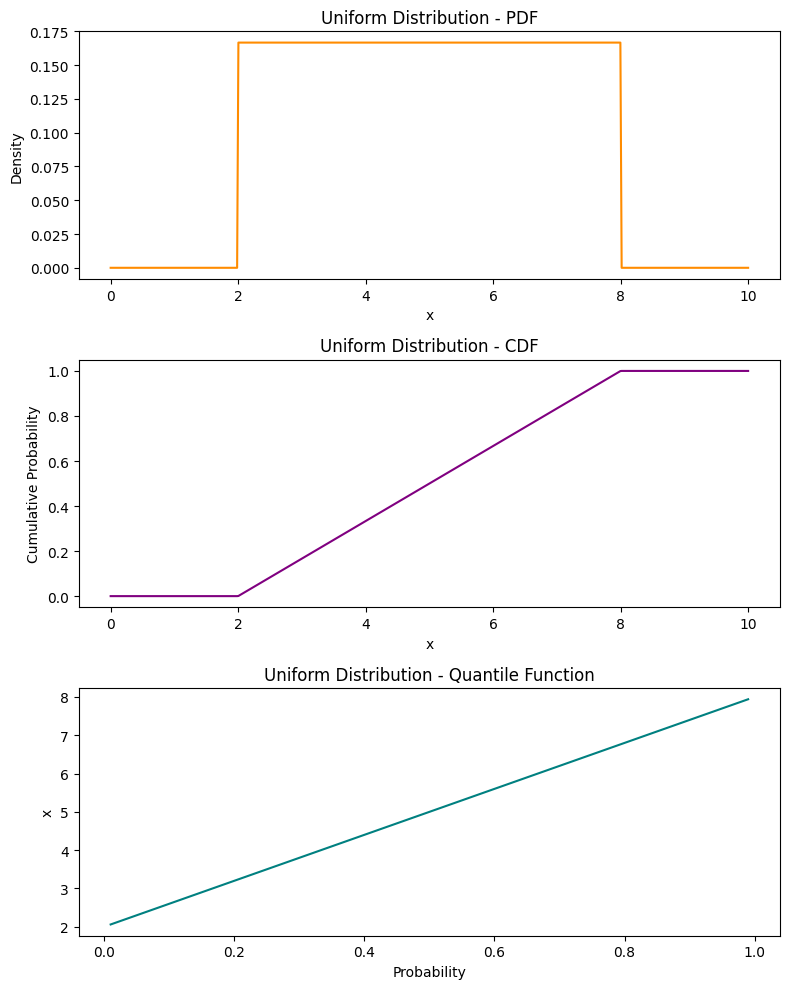

In [7]:
fig, ax = plt.subplots(3, 1, figsize=(8, 10))

ax[0].plot(x_uniform, uniform_pdf_values, color="darkorange")
ax[0].set_title("Uniform Distribution - PDF")
ax[0].set_xlabel("x")
ax[0].set_ylabel("Density")

ax[1].plot(x_uniform, uniform_cdf_values, color="purple")
ax[1].set_title("Uniform Distribution - CDF")
ax[1].set_xlabel("x")
ax[1].set_ylabel("Cumulative Probability")

ax[2].plot(p_values, uniform_ppf_values, color="teal")
ax[2].set_title("Uniform Distribution - Quantile Function")
ax[2].set_xlabel("Probability")
ax[2].set_ylabel("x")

plt.tight_layout()
plt.show()